In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
np.random.seed(444)
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input/"))


figure_size = (15,15)

# Any results you write to the current directory are saved as output.

/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWarning: Passing (type, 1) or 

['heart.csv']


In [2]:
df = pd.read_csv('../input/heart.csv')

In [3]:
def create_confusion_matrix(predictions, labels):
    
    confusion_matrix = {"TP": 0, "TN": 0, "FP": 0, "FN": 0}
    
    label_list = list(labels.values.flatten())

    label_index = 0
    
    for row in predictions:

        if row == label_list[label_index]:
            
            if row == 1:
                confusion_matrix["TP"] += 1
            else:
                confusion_matrix["TN"] += 1
        else:
            if row == 1:
                confusion_matrix["FP"] += 1
            else:
                confusion_matrix["FN"] += 1
        label_index += 1

    print(confusion_matrix)
    print("n:{}".format(label_index))
    return confusion_matrix

def perf(model):
    try:
        preds = model.predict_classes(X_test)
    except:
        preds = model.predict(X_test)
        
    print(classification_report(y_test, preds))
    create_confusion_matrix(preds, y_test)
    accuracy_score(preds, y_test)


    

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f94dea27550>]],
      dtype=object)

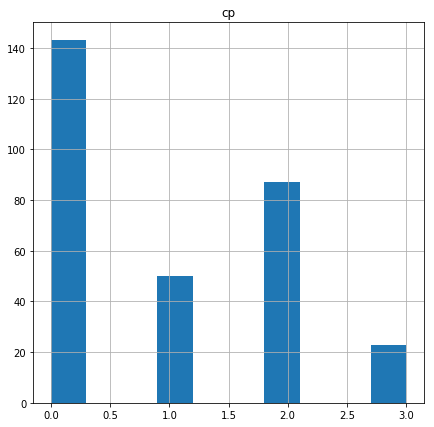

In [5]:
df.hist('cp', figsize=(7,7))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f94dc938e48>]],
      dtype=object)

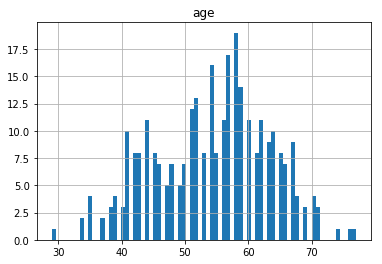

In [6]:
df.hist("age", bins=75)

In [7]:
unique_ages = pd.unique(df.age)
print("Number of unique ages: {}".format(len(unique_ages)))
unique_ages.sort(kind='mergesort')
display(unique_ages)

Number of unique ages: 41


array([29, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 74, 76, 77])

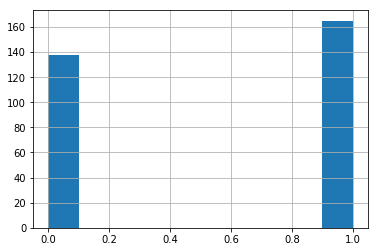

In [8]:
df.target.hist()

In [9]:
display(df.describe())
display(df.isna().sum())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f94dc7c1860>,
      dtype=object)

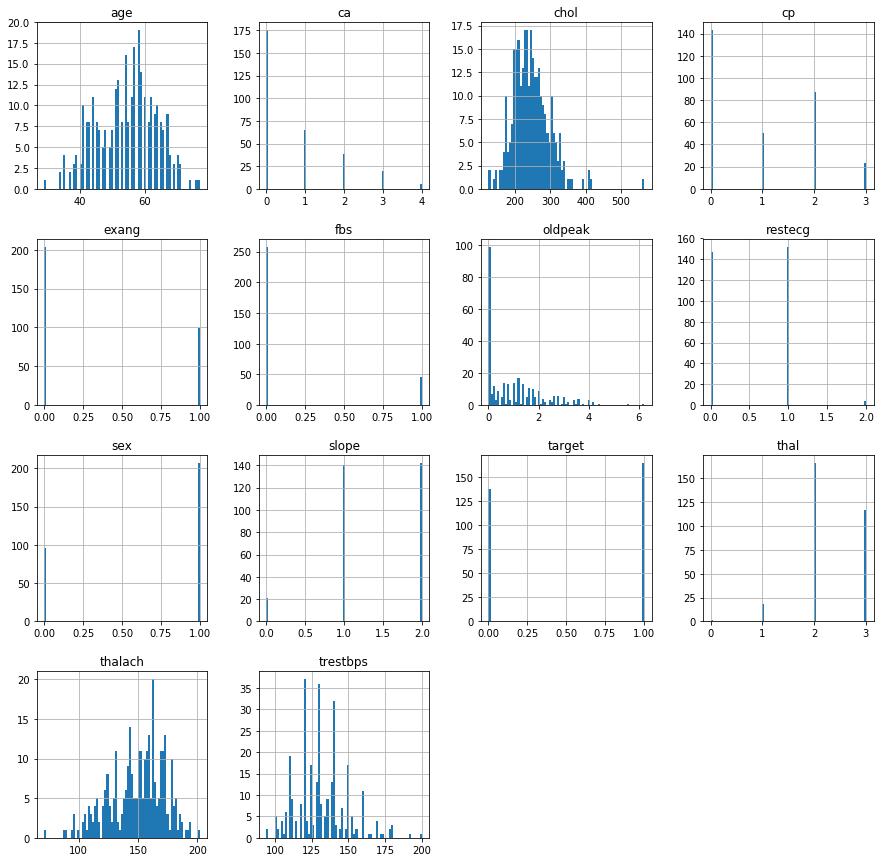

In [10]:
df.hist(bins=75, figsize=figure_size)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f94dc4912b0>,
      dtype=object)

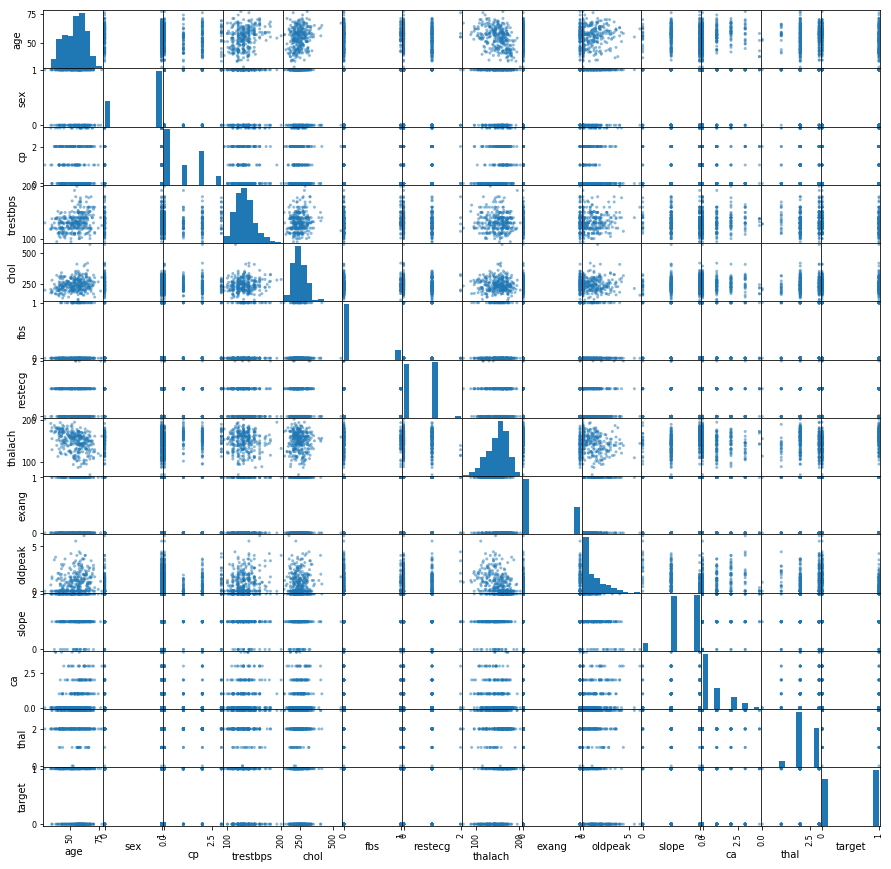

In [11]:
scatter_matrix(df, figsize=figure_size)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

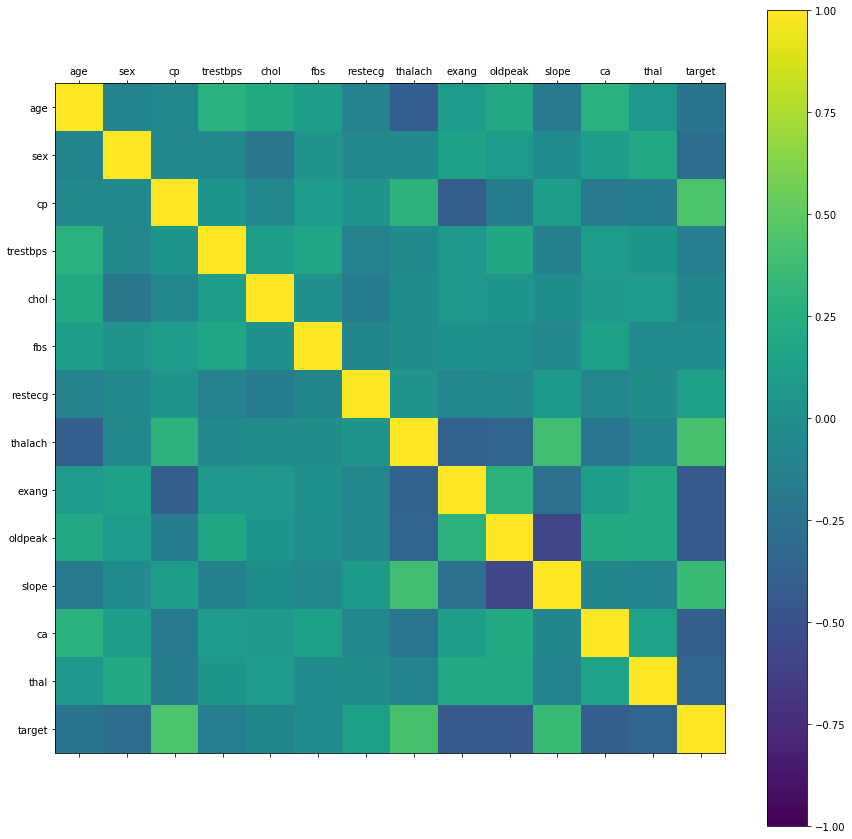

In [12]:
%matplotlib inline
correllations = df.corr()
fig = plt.figure(figsize=figure_size)
ax = fig.add_subplot(111)
cax = ax.matshow(correllations, vmin=-1, vmax=1)
fig.colorbar(cax)
names = df.columns
ticks = np.arange(0,len(names),1)
display(names)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)
plt.show()

This comes from the documentation for the original dataset from which this was derived. It is lightly edited for clarity.

1. age: age in years
2. sex: sex (1 = male; 0 = female)
3. cp: chest pain type
    * Value 1: typical angina
    * Value 2: atypical angina
    * Value 3: non-anginal pain
    * Value 4: asymptomatic
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral in mg/dl
6. fbs: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
7. restecg: resting electrocardiographic results
    * Value 0: normal
    * Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    * Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach: maximum heart rate achieved
9. exang: exercise induced angina (1 = yes; 0 = no)
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    * Value 1: upsloping
    * Value 2: flat
    * Value 3: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy
13. thal: 3 = normal; 6 = fixed defect; 7 = reversable defect

## Notable Columns

Because I want the models to train on the most non-invasive information, I will remove difficult to retrieve information such as cholesterol level, and fasting blood sugar. 



In [13]:
df.drop(['chol', 'fbs', 'ca', 'thal'], axis=1, inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 10 columns):
age         303 non-null int64
sex         303 non-null int64
cp          303 non-null int64
trestbps    303 non-null int64
restecg     303 non-null int64
thalach     303 non-null int64
exang       303 non-null int64
oldpeak     303 non-null float64
slope       303 non-null int64
target      303 non-null int64
dtypes: float64(1), int64(9)
memory usage: 23.8 KB


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
y = df.target
X  = df.drop('target', axis=1)
scaler = StandardScaler()
# Fit the scaler to the data contained in 'X'
scaler.fit(X)
# Use scaler.transform() on the X and store the results below
scaled_X = scaler.transform(X)

pca = PCA()
# call pca.fit() on the data stored in 'scaled_data'.
pca.fit(scaled_X)
x_pca = pca.transform(scaled_X)
# pca_k_means = KMeans(n_clusters=len(X.columns))
# pca_k_means.fit(x_pca)

In [16]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5)

In [17]:
def comp(model):
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['mse', 'mae', 'mape', 'cosine'])
    model.summary()
    return model

def fit(model):
    model.fit(X_train, list(y_train), batch_size=64, epochs=80, verbose=1, validation_data=(X_test, list(y_test)))
    return model

In [18]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [19]:
clf = DecisionTreeClassifier()
fitted = clf.fit(X_train, list(y_train))
perf(fitted)

              precision    recall  f1-score   support

           0       0.58      0.65      0.61        69
           1       0.68      0.60      0.64        83

    accuracy                           0.62       152
   macro avg       0.63      0.63      0.62       152
weighted avg       0.63      0.62      0.63       152

{'TP': 50, 'TN': 45, 'FP': 24, 'FN': 33}
n:152


In [20]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train,list(y_train))
perf(logreg)
# display(logregs.coef_)
# display(logregs.intercept_)


              precision    recall  f1-score   support

           0       0.90      0.68      0.78        69
           1       0.78      0.94      0.85        83

    accuracy                           0.82       152
   macro avg       0.84      0.81      0.81       152
weighted avg       0.84      0.82      0.82       152

{'TP': 78, 'TN': 47, 'FP': 22, 'FN': 5}
n:152


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [21]:
display(logreg.predict([X_test.iloc[5]]))
# df.to_csv('../input/saved.csv')


array([1])

In [22]:
from sklearn import linear_model

In [23]:
clf = linear_model.SGDClassifier(max_iter=1000, tol=1e-3)
clf.fit(X_train,list(y_train))
perf(clf)

              precision    recall  f1-score   support

           0       0.75      0.35      0.48        69
           1       0.62      0.90      0.74        83

    accuracy                           0.65       152
   macro avg       0.69      0.63      0.61       152
weighted avg       0.68      0.65      0.62       152

{'TP': 75, 'TN': 24, 'FP': 45, 'FN': 8}
n:152


In [24]:
from sklearn.naive_bayes import GaussianNB

In [25]:
clf = GaussianNB()
clf.fit(X_train, list(y_train))
perf(clf)

              precision    recall  f1-score   support

           0       0.91      0.74      0.82        69
           1       0.81      0.94      0.87        83

    accuracy                           0.85       152
   macro avg       0.86      0.84      0.84       152
weighted avg       0.86      0.85      0.85       152

{'TP': 78, 'TN': 51, 'FP': 18, 'FN': 5}
n:152


In [26]:
from sklearn.cluster import KMeans

In [27]:
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU
from keras.utils import to_categorical

Using TensorFlow backend.


In [28]:
small_model = Sequential()
small_model.add(Dense(9, input_shape=(9,)))
small_model.add(Dense(4, activation='relu'))
small_model.add(Dense(1, activation='sigmoid'))
comp(small_model)
fit(small_model)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 9)                 90        
_________________________________________________________________
dense_2 (Dense)              (None, 4)                 40        
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 5         
Total params: 135
Trainable params: 135
Non-trainable params: 0
_________________________________________________________________
Train on 151 samples, validate on 152 samples
Epoch 1/80
151/151 [==============================] - 1s 4ms/step - loss: 8.7529 - mean_squared_error: 0.5430 - mean_absolute_error: 0.5430 - mean_absolute_percentage_error: 107.5936 - cosine_proximity: 0.0000e+00 - val_loss: 8.8013 - val_mean_squared_error: 0.5461 - val_mean_absolute_error: 0.5461 - val_mean_absolute_percentage_error: 54.6053 - val_cosine_pro

In [29]:
perf(small_model)

              precision    recall  f1-score   support

           0       0.45      1.00      0.62        69
           1       0.00      0.00      0.00        83

    accuracy                           0.45       152
   macro avg       0.23      0.50      0.31       152
weighted avg       0.21      0.45      0.28       152

{'TP': 0, 'TN': 69, 'FP': 0, 'FN': 83}
n:152


/opt/conda/lib/python3.6/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


In [30]:
small_relu_nn = Sequential()
small_relu_nn.add(Dense(9, input_shape=(9,)))
small_relu_nn.add(LeakyReLU(alpha=0.05))
small_relu_nn.add(Dense(4))
small_relu_nn.add(LeakyReLU(alpha=0.05))
small_relu_nn.add(Dense(1, activation='sigmoid'))

comp(small_relu_nn)
fit(small_relu_nn)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 9)                 90        
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 9)                 0         
_________________________________________________________________
dense_5 (Dense)              (None, 4)                 40        
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 4)                 0         
_________________________________________________________________
dense_6 (Dense)              (None, 1)                 5         
Total params: 135
Trainable params: 135
Non-trainable params: 0
_________________________________________________________________
Train on 151 samples, validate on 152 samples
Epoch 1/80
151/151 [==============================] - 0s 3ms/step - loss: 1.1695 - mean_squared_er

In [31]:
perf(small_relu_nn)

              precision    recall  f1-score   support

           0       0.63      0.65      0.64        69
           1       0.70      0.69      0.70        83

    accuracy                           0.67       152
   macro avg       0.67      0.67      0.67       152
weighted avg       0.67      0.67      0.67       152

{'TP': 57, 'TN': 45, 'FP': 24, 'FN': 26}
n:152


In [32]:
med_model = Sequential()
med_model.add(Dense(9, input_shape=(9,)))
med_model.add(LeakyReLU(alpha=0.05))
med_model.add(Dense(6))
med_model.add(LeakyReLU(alpha=0.05))
med_model.add(Dense(2))
med_model.add(LeakyReLU(alpha=0.05))
med_model.add(Dense(1, activation='sigmoid'))

comp(med_model)
fit(med_model)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_7 (Dense)              (None, 9)                 90        
_________________________________________________________________
leaky_re_lu_3 (LeakyReLU)    (None, 9)                 0         
_________________________________________________________________
dense_8 (Dense)              (None, 6)                 60        
_________________________________________________________________
leaky_re_lu_4 (LeakyReLU)    (None, 6)                 0         
_________________________________________________________________
dense_9 (Dense)              (None, 2)                 14        
_________________________________________________________________
leaky_re_lu_5 (LeakyReLU)    (None, 2)                 0         
_________________________________________________________________
dense_10 (Dense)             (None, 1)                 3         
Total para

In [33]:
perf(med_model)

              precision    recall  f1-score   support

           0       0.45      1.00      0.62        69
           1       0.00      0.00      0.00        83

    accuracy                           0.45       152
   macro avg       0.23      0.50      0.31       152
weighted avg       0.21      0.45      0.28       152

{'TP': 0, 'TN': 69, 'FP': 0, 'FN': 83}
n:152


In [34]:
med_leaky_model = Sequential()
med_leaky_model.add(Dense(9, input_shape=(9, )))
med_leaky_model.add(LeakyReLU(alpha=0.05))
med_leaky_model.add(Dense(6))
med_leaky_model.add(LeakyReLU(alpha=0.05))
med_leaky_model.add(Dense(3))
med_leaky_model.add(LeakyReLU(alpha=0.05))
med_leaky_model.add(Dense(3))
med_leaky_model.add(LeakyReLU(alpha=0.05))
med_leaky_model.add(Dense(1))

comp(med_leaky_model)
fit(med_leaky_model)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_11 (Dense)             (None, 9)                 90        
_________________________________________________________________
leaky_re_lu_6 (LeakyReLU)    (None, 9)                 0         
_________________________________________________________________
dense_12 (Dense)             (None, 6)                 60        
_________________________________________________________________
leaky_re_lu_7 (LeakyReLU)    (None, 6)                 0         
_________________________________________________________________
dense_13 (Dense)             (None, 3)                 21        
_________________________________________________________________
leaky_re_lu_8 (LeakyReLU)    (None, 3)                 0         
_________________________________________________________________
dense_14 (Dense)             (None, 3)                 12        
__________

In [35]:
perf(med_leaky_model)

              precision    recall  f1-score   support

           0       0.67      0.54      0.60        69
           1       0.67      0.78      0.72        83

    accuracy                           0.67       152
   macro avg       0.67      0.66      0.66       152
weighted avg       0.67      0.67      0.67       152

{'TP': 65, 'TN': 37, 'FP': 32, 'FN': 18}
n:152


In [36]:
from keras.layers import Dropout
tail_model = Sequential()
tail_model.add(Dense(9, activation='relu', input_shape=(9,)))
tail_model.add(Dense(18, activation='relu'))
tail_model.add(Dense(9, activation='relu'))
tail_model.add(Dense(7, activation='relu'))
tail_model.add(Dense(4, activation='relu'))
tail_model.add(Dense(1, activation='sigmoid'))

comp(tail_model)
fit(tail_model)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_16 (Dense)             (None, 9)                 90        
_________________________________________________________________
dense_17 (Dense)             (None, 18)                180       
_________________________________________________________________
dense_18 (Dense)             (None, 9)                 171       
_________________________________________________________________
dense_19 (Dense)             (None, 7)                 70        
_________________________________________________________________
dense_20 (Dense)             (None, 4)                 32        
_________________________________________________________________
dense_21 (Dense)             (None, 1)                 5         
Total params: 548
Trainable params: 548
Non-trainable params: 0
_________________________________________________________________
Train on 151

In [37]:
perf(tail_model)

              precision    recall  f1-score   support

           0       0.83      0.22      0.34        69
           1       0.60      0.96      0.74        83

    accuracy                           0.62       152
   macro avg       0.72      0.59      0.54       152
weighted avg       0.70      0.62      0.56       152

{'TP': 80, 'TN': 15, 'FP': 54, 'FN': 3}
n:152


In [38]:
from keras.layers import Dropout, LeakyReLU
leakly_large_model = Sequential()
leakly_large_model.add(Dense(16, input_shape=(9,)))
leakly_large_model.add(LeakyReLU(alpha=0.05))
leakly_large_model.add(Dense(12))
leakly_large_model.add(LeakyReLU(alpha=0.05))
leakly_large_model.add(Dense(8))
leakly_large_model.add(LeakyReLU(alpha=0.05))
leakly_large_model.add(Dropout(.5))
leakly_large_model.add(Dense(4))
leakly_large_model.add(LeakyReLU(alpha=0.05))
leakly_large_model.add(Dense(1, activation='sigmoid'))

comp(leakly_large_model)
fit(leakly_large_model)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_22 (Dense)             (None, 16)                160       
_________________________________________________________________
leaky_re_lu_10 (LeakyReLU)   (None, 16)                0         
_________________________________________________________________
dense_23 (Dense)             (None, 12)                204       
_________________________________________________________________
leaky_re_lu_11 (LeakyReLU)   (None, 12)                0         
_________________________________________________________________
dense_24 (Dense)             (None, 8)                 104       
_________________________________________________________________
leaky_re_lu_12 (LeakyReLU)   (None, 8)                 0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 8)                 0         
__________

In [39]:
perf(leakly_large_model)

              precision    recall  f1-score   support

           0       0.62      0.77      0.68        69
           1       0.76      0.60      0.67        83

    accuracy                           0.68       152
   macro avg       0.69      0.69      0.68       152
weighted avg       0.69      0.68      0.68       152

{'TP': 50, 'TN': 53, 'FP': 16, 'FN': 33}
n:152


In [40]:
from keras.layers import Dropout
droppy_model = Sequential()
droppy_model.add(Dense(9, activation='relu', input_shape=(9,)))
droppy_model.add(Dense(4, activation='relu'))
droppy_model.add(Dropout(0.2))
droppy_model.add(Dense(1, activation='sigmoid'))

comp(droppy_model)
fit(droppy_model)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_27 (Dense)             (None, 9)                 90        
_________________________________________________________________
dense_28 (Dense)             (None, 4)                 40        
_________________________________________________________________
dropout_2 (Dropout)          (None, 4)                 0         
_________________________________________________________________
dense_29 (Dense)             (None, 1)                 5         
Total params: 135
Trainable params: 135
Non-trainable params: 0
_________________________________________________________________
Train on 151 samples, validate on 152 samples
Epoch 1/80
151/151 [==============================] - 1s 6ms/step - loss: 5.9784 - mean_squared_error: 0.4283 - mean_absolute_error: 0.4654 - mean_absolute_percentage_error: 392374547.2848 - cosine_proximity: -0.5430 - val_loss: 7

In [41]:
perf(droppy_model)

              precision    recall  f1-score   support

           0       1.00      0.01      0.03        69
           1       0.55      1.00      0.71        83

    accuracy                           0.55       152
   macro avg       0.77      0.51      0.37       152
weighted avg       0.75      0.55      0.40       152

{'TP': 83, 'TN': 1, 'FP': 68, 'FN': 0}
n:152
